In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")

category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)


Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


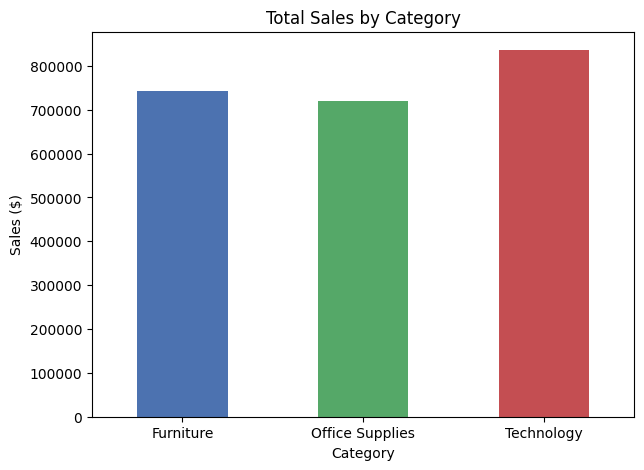

In [ ]:

plt.figure(figsize=(7,5))
category_sales.plot(kind='bar', color=['#4c72b0', '#55a868', '#c44e52'])
plt.title("Total Sales by Category")
plt.ylabel("Sales ($)")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()



Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


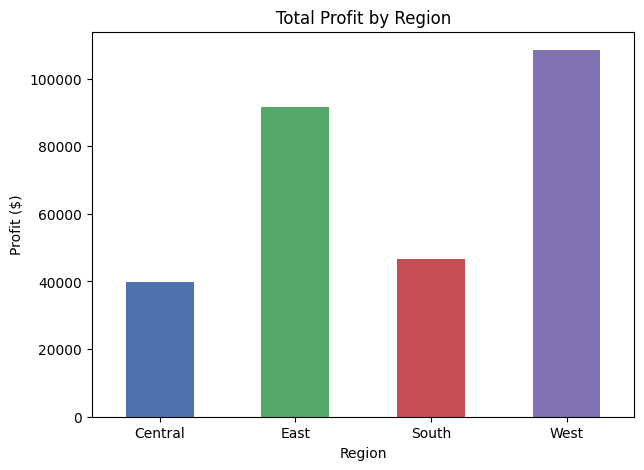

In [ ]:


region_profit = df.groupby('Region')['Profit'].sum()
print(region_profit)

plt.figure(figsize=(7,5))
region_profit.plot(kind='bar', color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])
plt.title("Total Profit by Region")
plt.ylabel("Profit ($)")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.show()

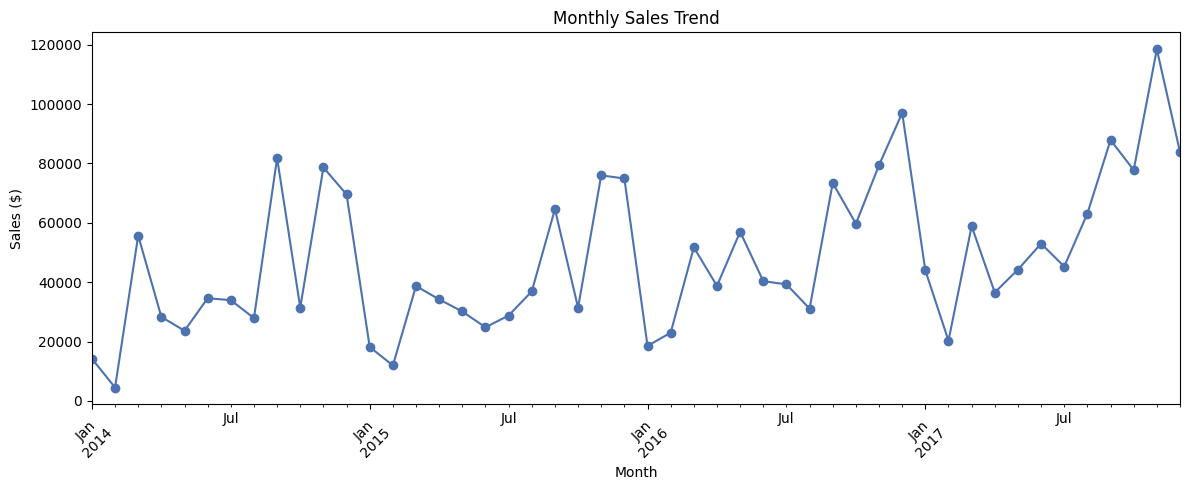

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Month'] = df['Order Date'].dt.to_period('M')


monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line', marker='o', color='#4c72b0')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales ($)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [15]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Monthly sales ko numbers mein convert karo (Model ko numbers chahiye, dates nahi)
monthly_sales_df = monthly_sales.reset_index()
monthly_sales_df['Month_Number'] = range(1, len(monthly_sales_df) + 1)

# X (input) aur y (output) define karo
X = monthly_sales_df[['Month_Number']]
y = monthly_sales_df['Sales']

# Model train karo
model = LinearRegression()
model.fit(X, y)

# Agle 3 mahine ka prediction karo
future_months = np.array([[len(monthly_sales_df)+1], [len(monthly_sales_df)+2], [len(monthly_sales_df)+3]])
predictions = model.predict(future_months)

print("Next 3 months sales prediction:")
for i, pred in enumerate(predictions, 1):
    print(f"Month +{i}: ${pred:,.2f}")

Next 3 months sales prediction:
Month +1: $69,957.54
Month +2: $70,859.54
Month +3: $71,761.55


c:\Users\91898\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
